# ISIC 2018 — Exploratory Data Analysis
Statistical analysis of dermoscopic images, segmentation masks, and attribute annotations (Tasks 1 & 2).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

BASE_DIR = Path(".")
TASK1_GT = BASE_DIR / "ISIC2018_Task1_Training_GroundTruth"
TASK1_2_INPUT = BASE_DIR / "ISIC2018_Task1-2_Training_Input"
TASK2_GT = BASE_DIR / "ISIC2018_Task2_Training_GroundTruth_v3"
IMAGE_DIR = "image"
os.makedirs(IMAGE_DIR, exist_ok=True)

attributes = ["globules", "milia_like_cyst", "negative_network", "pigment_network", "streaks"]

print("Setup complete.")

Setup complete.


## 1. Dataset Overview
Count the number of images and masks in each task directory.

In [13]:
def count_files(directory, ext=None):
    if not directory.exists():
        return 0
    files = list(directory.iterdir())
    if ext:
        files = [f for f in files if f.suffix.lower() == ext]
    return len(files)

task1_2_images = count_files(TASK1_2_INPUT, ".jpg")
task1_masks = count_files(TASK1_GT, ".png")
task2_attrs = count_files(TASK2_GT, ".png")

summary = pd.DataFrame({
    "Directory": [
        "Task 1-2 Training Input (dermoscopic images)",
        "Task 1 Ground Truth (segmentation masks)",
        "Task 2 Ground Truth v3 (attribute masks)",
    ],
    "File Count": [task1_2_images, task1_masks, task2_attrs],
})
print(summary.to_string(index=False))

# Unique images and attributes in Task 2
task2_files = [f.stem for f in TASK2_GT.glob("*.png")]
task2_image_ids = set()
for fname in task2_files:
    parts = fname.split("_attribute_")
    if len(parts) == 2:
        task2_image_ids.add(parts[0])

image_ids_task2 = sorted(task2_image_ids)
print(f"\nTask 2: {len(image_ids_task2)} unique images × {len(attributes)} attributes = {len(image_ids_task2) * len(attributes)} masks")

                                   Directory  File Count
Task 1-2 Training Input (dermoscopic images)        2594
    Task 1 Ground Truth (segmentation masks)        2594
    Task 2 Ground Truth v3 (attribute masks)       12970

Task 2: 2594 unique images × 5 attributes = 12970 masks


## 2. Image Resolution Analysis
Analyze width, height, and aspect ratio distributions for Task 1-2 images.

In [14]:
def get_image_stats(directory, ext=".jpg", sample_size=300):
    files = sorted(directory.glob(f"*{ext}"))
    if len(files) > sample_size:
        rng = np.random.default_rng(42)
        files = list(rng.choice(files, sample_size, replace=False))
    records = []
    for f in files:
        img = Image.open(f)
        w, h = img.size
        records.append({"file": f.stem, "width": w, "height": h, "aspect_ratio": w / h})
        img.close()
    return pd.DataFrame(records)

stats_task12 = get_image_stats(TASK1_2_INPUT, ".jpg", sample_size=300)

print("Task 1-2 image stats (sampled", len(stats_task12), "images):")
print(stats_task12[["width", "height", "aspect_ratio"]].describe().round(2).to_string())

Task 1-2 image stats (sampled 300 images):
         width   height  aspect_ratio
count   300.00   300.00        300.00
mean   2947.29  2005.28          1.43
std    1826.11  1174.80          0.11
min     576.00   542.00          0.75
25%    1024.00   768.00          1.33
50%    3008.00  2000.00          1.50
75%    4288.00  2848.00          1.51
max    6708.00  4461.00          1.52


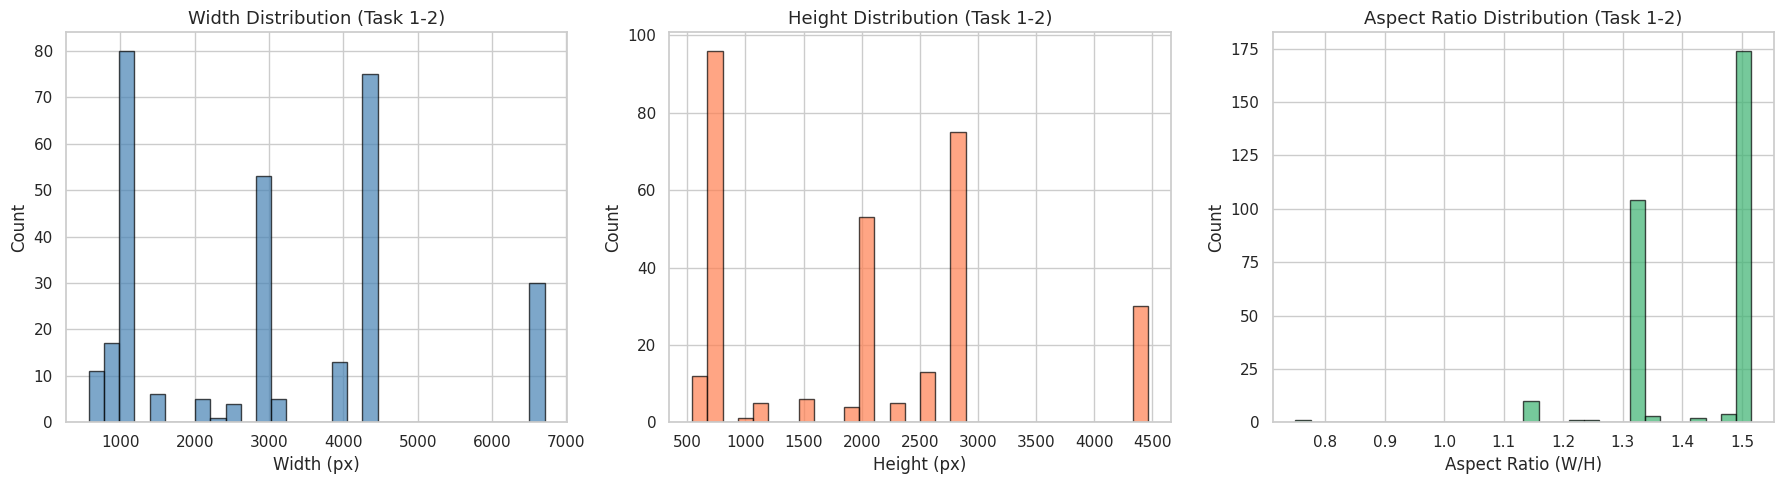

Saved: image/image_resolution_distribution.png


In [15]:
# Figure 1: Image Resolution Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(stats_task12["width"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Width Distribution (Task 1-2)", fontsize=13)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")

axes[1].hist(stats_task12["height"], bins=30, color="coral", edgecolor="black", alpha=0.7)
axes[1].set_title("Height Distribution (Task 1-2)", fontsize=13)
axes[1].set_xlabel("Height (px)")
axes[1].set_ylabel("Count")

axes[2].hist(stats_task12["aspect_ratio"], bins=30, color="mediumseagreen", edgecolor="black", alpha=0.7)
axes[2].set_title("Aspect Ratio Distribution (Task 1-2)", fontsize=13)
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_ylabel("Count")

plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/image_resolution_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/image_resolution_distribution.png")

## 3. Attribute Annotation Analysis
Analyze the 5 dermoscopic structure attributes: positive annotation rates and pixel coverage.

In [16]:
# Compute attribute statistics
sample_size = min(200, len(image_ids_task2))
rng = np.random.default_rng(42)
sampled_ids = list(rng.choice(image_ids_task2, sample_size, replace=False))

attr_positive_counts = {attr: 0 for attr in attributes}
attr_pixel_fractions = {attr: [] for attr in attributes}

for img_id in sampled_ids:
    for attr in attributes:
        mask_path = TASK2_GT / f"{img_id}_attribute_{attr}.png"
        if mask_path.exists():
            mask = np.array(Image.open(mask_path))
            total_pixels = mask.size
            positive_pixels = np.count_nonzero(mask)
            fraction = positive_pixels / total_pixels
            if positive_pixels > 0:
                attr_positive_counts[attr] += 1
            attr_pixel_fractions[attr].append(fraction)

pos_rates = {attr: attr_positive_counts[attr] / sample_size * 100 for attr in attributes}

print(f"Sampled {sample_size} images from {len(image_ids_task2)} total.")
for attr in attributes:
    mean_frac = np.mean(attr_pixel_fractions[attr]) * 100
    print(f"  {attr:25s}: {attr_positive_counts[attr]:4d}/{sample_size} positive ({pos_rates[attr]:.1f}%), "
          f"mean pixel coverage: {mean_frac:.2f}%")

Sampled 200 images from 2594 total.
  globules                 :   50/200 positive (25.0%), mean pixel coverage: 0.53%
  milia_like_cyst          :   57/200 positive (28.5%), mean pixel coverage: 0.23%
  negative_network         :   13/200 positive (6.5%), mean pixel coverage: 0.19%
  pigment_network          :  118/200 positive (59.0%), mean pixel coverage: 3.74%
  streaks                  :    7/200 positive (3.5%), mean pixel coverage: 0.06%


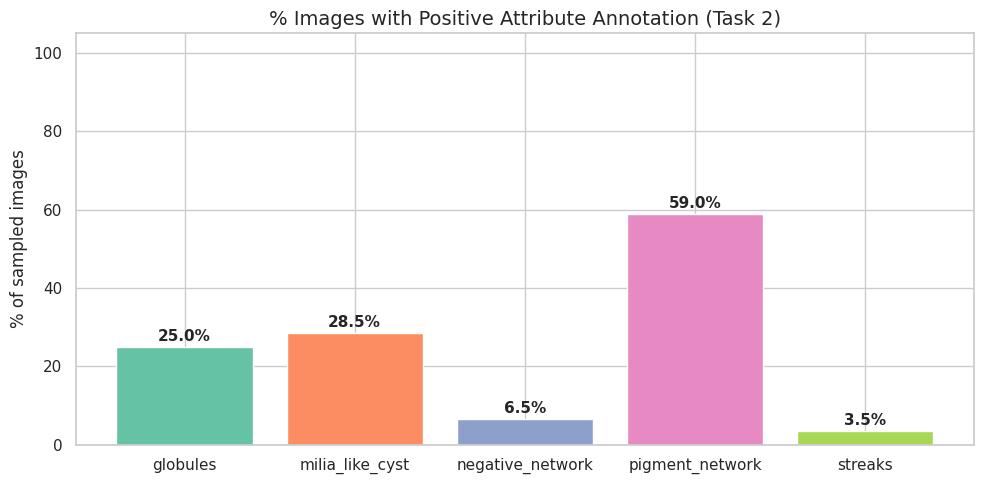

Saved: image/attribute_positive_rate.png


In [17]:
# Figure 2: Attribute Positive Annotation Rate
fig, ax = plt.subplots(figsize=(10, 5))
colors_attr = sns.color_palette("Set2", len(attributes))
bars = ax.bar(pos_rates.keys(), pos_rates.values(), color=colors_attr)
ax.set_title("% Images with Positive Attribute Annotation (Task 2)", fontsize=14)
ax.set_ylabel("% of sampled images")
ax.set_ylim(0, 105)
for bar, val in zip(bars, pos_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/attribute_positive_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/attribute_positive_rate.png")

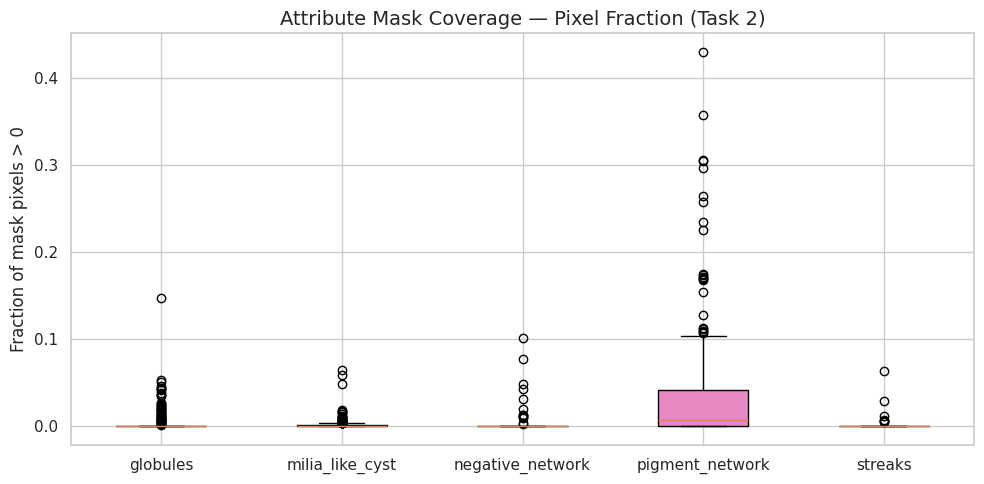

Saved: image/attribute_mask_coverage.png


In [18]:
# Figure 3: Attribute Mask Coverage (pixel fraction)
fig, ax = plt.subplots(figsize=(10, 5))
box_data = [attr_pixel_fractions[attr] for attr in attributes]
bp = ax.boxplot(box_data, tick_labels=attributes, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_attr):
    patch.set_facecolor(color)
ax.set_title("Attribute Mask Coverage — Pixel Fraction (Task 2)", fontsize=14)
ax.set_ylabel("Fraction of mask pixels > 0")
plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/attribute_mask_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/attribute_mask_coverage.png")

## 4. Segmentation Mask Analysis
Analyze lesion size distribution based on Task 1 segmentation masks.

In [19]:
# Compute lesion size statistics
seg_masks = sorted(TASK1_GT.glob("*_segmentation.png"))
sample_size_seg = min(300, len(seg_masks))
rng = np.random.default_rng(42)
sampled_masks = list(rng.choice(seg_masks, sample_size_seg, replace=False))

lesion_fractions = []
for mask_path in sampled_masks:
    mask = np.array(Image.open(mask_path))
    total = mask.size
    positive = np.count_nonzero(mask)
    lesion_fractions.append(positive / total)

lesion_fractions = np.array(lesion_fractions)

print(f"Sampled {sample_size_seg} segmentation masks from {len(seg_masks)} total.")
print(f"Lesion area — mean: {lesion_fractions.mean()*100:.1f}%, "
      f"median: {np.median(lesion_fractions)*100:.1f}%, "
      f"min: {lesion_fractions.min()*100:.1f}%, max: {lesion_fractions.max()*100:.1f}%")

Sampled 300 segmentation masks from 2594 total.
Lesion area — mean: 21.7%, median: 12.2%, min: 0.4%, max: 98.7%


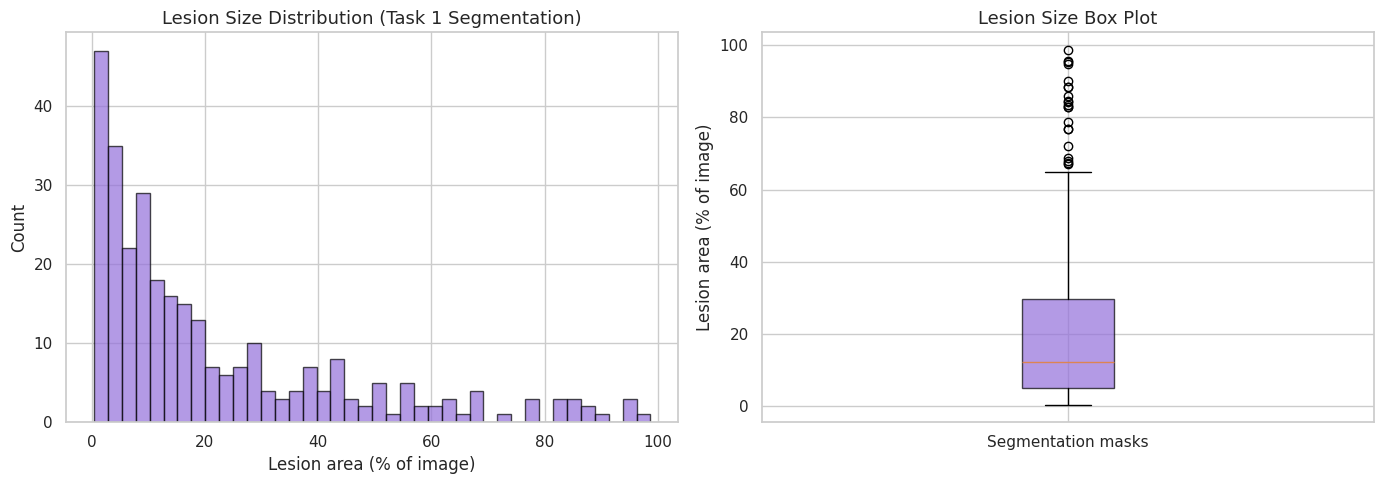

Saved: image/lesion_size_distribution.png


In [20]:
# Figure 4: Lesion Size Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lesion_fractions * 100, bins=40, color="mediumpurple", edgecolor="black", alpha=0.7)
axes[0].set_title("Lesion Size Distribution (Task 1 Segmentation)", fontsize=13)
axes[0].set_xlabel("Lesion area (% of image)")
axes[0].set_ylabel("Count")

axes[1].boxplot(lesion_fractions * 100, vert=True, patch_artist=True,
                boxprops=dict(facecolor="mediumpurple", alpha=0.7))
axes[1].set_title("Lesion Size Box Plot", fontsize=13)
axes[1].set_ylabel("Lesion area (% of image)")
axes[1].set_xticklabels(["Segmentation masks"])

plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/lesion_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/lesion_size_distribution.png")

## 5. Sample Overlays
Visualize dermoscopic images with segmentation and attribute mask overlays.

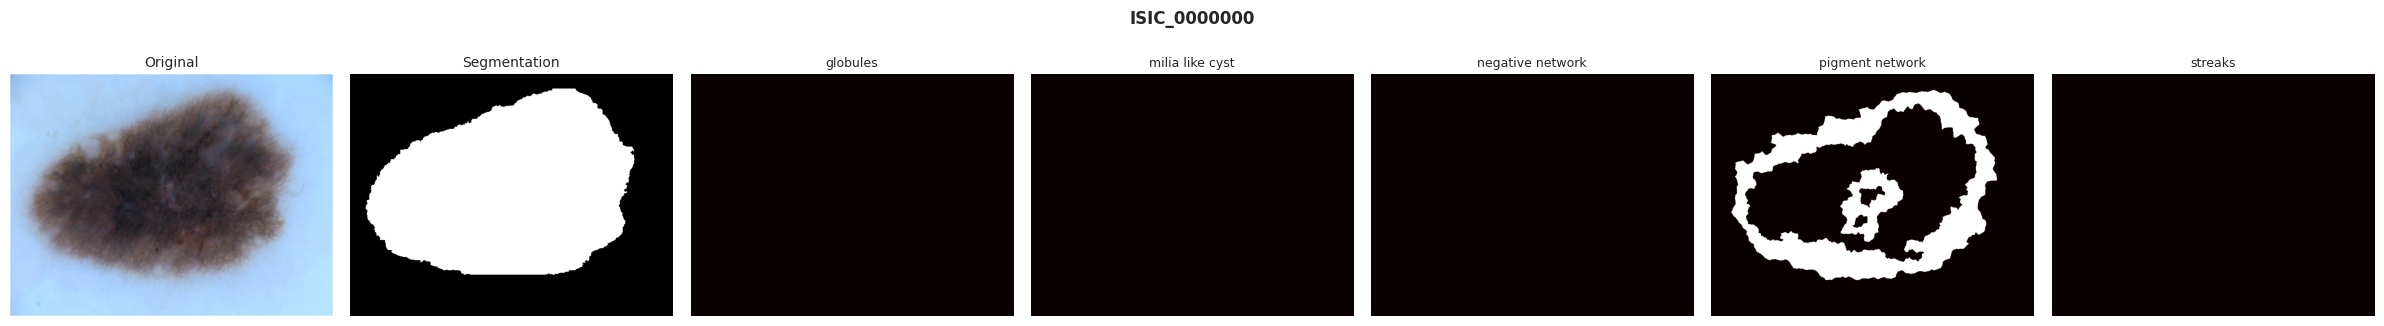

Saved: image/sample_overlay_1.png


In [21]:
# Figure 5: Sample Overlay 1
sample_input_files = sorted(TASK1_2_INPUT.glob("*.jpg"))[:2]
img_path = sample_input_files[0]
img_id = img_path.stem

fig, axes = plt.subplots(1, 7, figsize=(24, 3.5))
img = Image.open(img_path)
axes[0].imshow(img)
axes[0].set_title("Original", fontsize=10)
axes[0].axis("off")

seg_path = TASK1_GT / f"{img_id}_segmentation.png"
if seg_path.exists():
    seg = Image.open(seg_path)
    axes[1].imshow(seg, cmap="gray")
    axes[1].set_title("Segmentation", fontsize=10)
axes[1].axis("off")

for j, attr in enumerate(attributes):
    attr_path = TASK2_GT / f"{img_id}_attribute_{attr}.png"
    if attr_path.exists():
        attr_mask = Image.open(attr_path)
        axes[j + 2].imshow(attr_mask, cmap="hot")
        axes[j + 2].set_title(attr.replace("_", " "), fontsize=9)
    axes[j + 2].axis("off")

fig.suptitle(img_id, fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/sample_overlay_1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/sample_overlay_1.png")

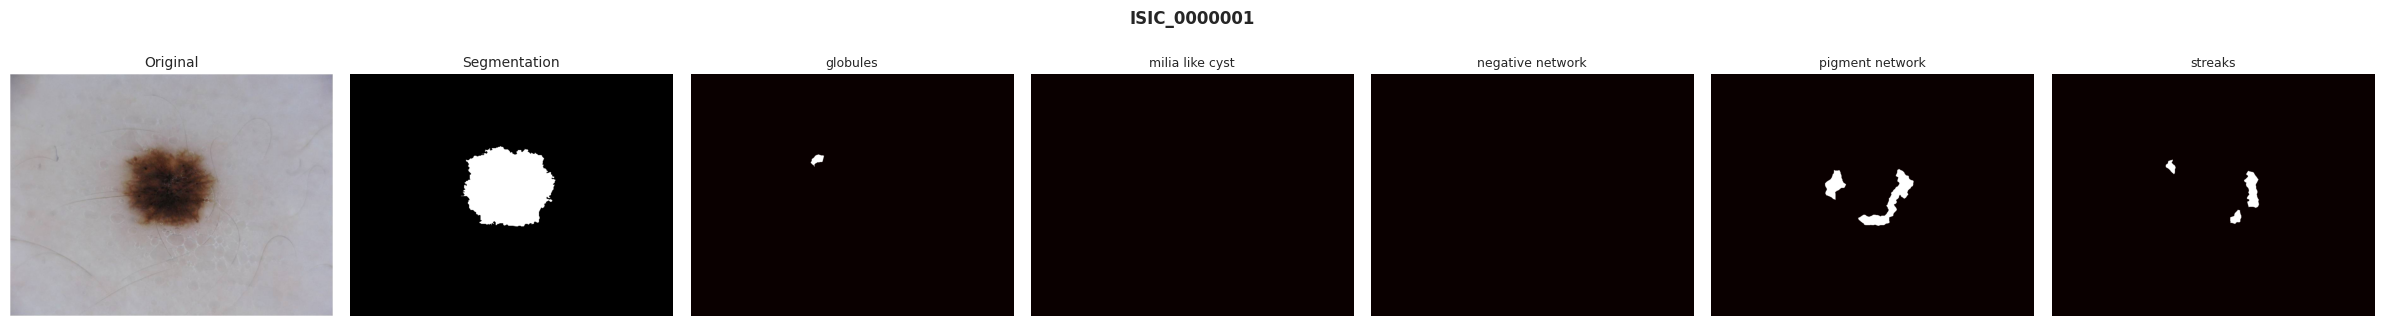

Saved: image/sample_overlay_2.png


In [22]:
# Figure 6: Sample Overlay 2
img_path = sample_input_files[1]
img_id = img_path.stem

fig, axes = plt.subplots(1, 7, figsize=(24, 3.5))
img = Image.open(img_path)
axes[0].imshow(img)
axes[0].set_title("Original", fontsize=10)
axes[0].axis("off")

seg_path = TASK1_GT / f"{img_id}_segmentation.png"
if seg_path.exists():
    seg = Image.open(seg_path)
    axes[1].imshow(seg, cmap="gray")
    axes[1].set_title("Segmentation", fontsize=10)
axes[1].axis("off")

for j, attr in enumerate(attributes):
    attr_path = TASK2_GT / f"{img_id}_attribute_{attr}.png"
    if attr_path.exists():
        attr_mask = Image.open(attr_path)
        axes[j + 2].imshow(attr_mask, cmap="hot")
        axes[j + 2].set_title(attr.replace("_", " "), fontsize=9)
    axes[j + 2].axis("off")

fig.suptitle(img_id, fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/sample_overlay_2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/sample_overlay_2.png")

## 6. Annotation Quality Assessment
Analyze attribute co-occurrence, unlabeled images, and annotation distribution.

In [23]:
# Compute co-occurrence matrix and attributes-per-image statistics
sample_size_qual = min(300, len(image_ids_task2))
rng = np.random.default_rng(123)
sampled_ids_qual = list(rng.choice(image_ids_task2, sample_size_qual, replace=False))

attr_binary = np.zeros((sample_size_qual, len(attributes)), dtype=int)
no_attr_count = 0

for i, img_id in enumerate(sampled_ids_qual):
    any_positive = False
    for j, attr in enumerate(attributes):
        mask_path = TASK2_GT / f"{img_id}_attribute_{attr}.png"
        if mask_path.exists():
            mask = np.array(Image.open(mask_path))
            if np.any(mask > 0):
                attr_binary[i, j] = 1
                any_positive = True
    if not any_positive:
        no_attr_count += 1

cooccurrence = np.zeros((len(attributes), len(attributes)), dtype=int)
for i in range(len(attributes)):
    for j in range(len(attributes)):
        cooccurrence[i, j] = np.sum(attr_binary[:, i] & attr_binary[:, j])

attr_per_image = attr_binary.sum(axis=1)

print(f"Sampled {sample_size_qual} images.")
print(f"Images with NO positive attribute: {no_attr_count} ({no_attr_count/sample_size_qual*100:.1f}%)")
print(f"Mean attributes per image: {attr_per_image.mean():.2f}")

Sampled 300 images.
Images with NO positive attribute: 63 (21.0%)
Mean attributes per image: 1.16


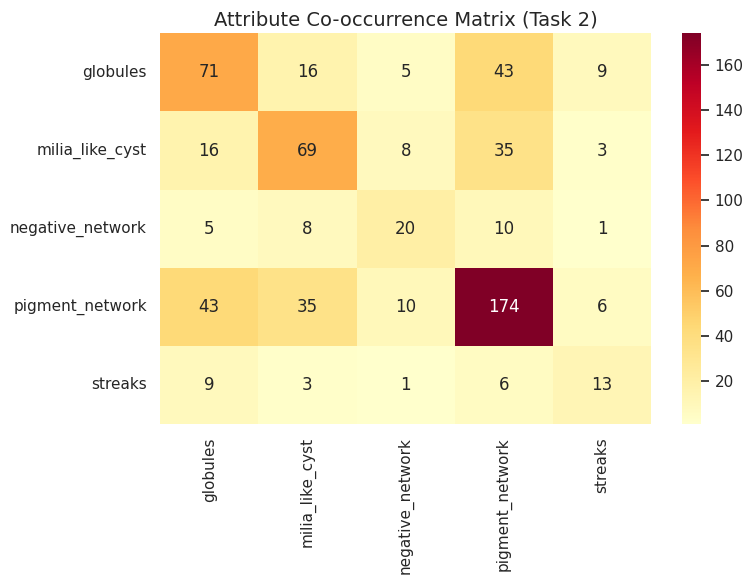

Saved: image/attribute_cooccurrence.png


In [24]:
# Figure 7: Attribute Co-occurrence Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooccurrence, annot=True, fmt="d", xticklabels=attributes, yticklabels=attributes,
            cmap="YlOrRd", ax=ax)
ax.set_title("Attribute Co-occurrence Matrix (Task 2)", fontsize=14)
plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/attribute_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/attribute_cooccurrence.png")

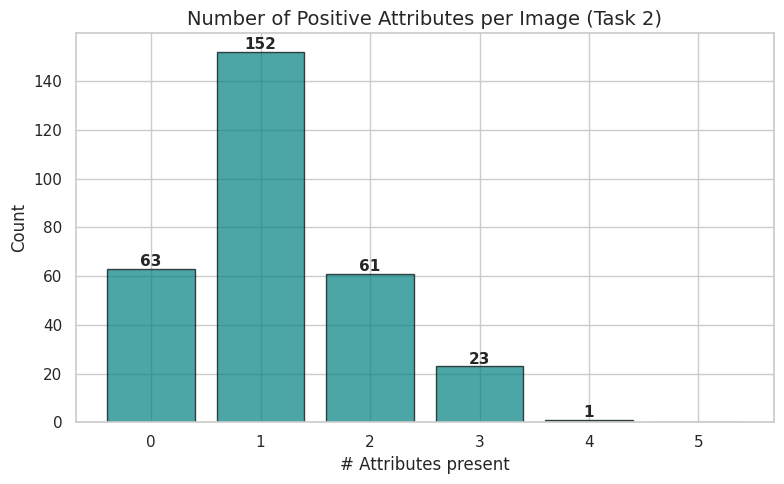

Saved: image/attributes_per_image.png


In [25]:
# Figure 8: Number of Positive Attributes per Image
fig, ax = plt.subplots(figsize=(8, 5))
counts_per_n = [int(np.sum(attr_per_image == n)) for n in range(0, len(attributes) + 1)]
bars = ax.bar(range(0, len(attributes) + 1), counts_per_n, color="teal", edgecolor="black", alpha=0.7)
for bar, val in zip(bars, counts_per_n):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title("Number of Positive Attributes per Image (Task 2)", fontsize=14)
ax.set_xlabel("# Attributes present")
ax.set_ylabel("Count")
ax.set_xticks(range(0, len(attributes) + 1))
plt.tight_layout()
fig.savefig(f"{IMAGE_DIR}/attributes_per_image.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: image/attributes_per_image.png")

## 7. Summary Statistics
Print a consolidated summary of all key statistics.

In [26]:
print("=" * 60)
print("KEY STATISTICS (Tasks 1 & 2)")
print("=" * 60)
print(f"Dermoscopic images (Task 1-2): {task1_2_images}")
print(f"Segmentation masks (Task 1): {task1_masks}")
print(f"Attribute masks (Task 2): {task2_attrs} ({task2_attrs // 5} images × 5 attributes)")
print(f"\nImage resolution (Task 1-2):")
print(f"  Width: {stats_task12['width'].min()} – {stats_task12['width'].max()} px")
print(f"  Height: {stats_task12['height'].min()} – {stats_task12['height'].max()} px")
print(f"\nAttribute positive rates (sampled {sample_size}):")
for attr in attributes:
    print(f"  {attr:25s}: {pos_rates[attr]:.1f}%  (coverage: {np.mean(attr_pixel_fractions[attr])*100:.2f}%)")
print(f"\nUnlabeled images: {no_attr_count}/{sample_size_qual} ({no_attr_count/sample_size_qual*100:.1f}%)")
print(f"Mean attributes/image: {attr_per_image.mean():.2f}")
print(f"\nLesion area (sampled {sample_size_seg}):")
print(f"  Mean: {lesion_fractions.mean()*100:.1f}%, Median: {np.median(lesion_fractions)*100:.1f}%")
print(f"  Range: {lesion_fractions.min()*100:.1f}% – {lesion_fractions.max()*100:.1f}%")

KEY STATISTICS (Tasks 1 & 2)
Dermoscopic images (Task 1-2): 2594
Segmentation masks (Task 1): 2594
Attribute masks (Task 2): 12970 (2594 images × 5 attributes)

Image resolution (Task 1-2):
  Width: 576 – 6708 px
  Height: 542 – 4461 px

Attribute positive rates (sampled 200):
  globules                 : 25.0%  (coverage: 0.53%)
  milia_like_cyst          : 28.5%  (coverage: 0.23%)
  negative_network         : 6.5%  (coverage: 0.19%)
  pigment_network          : 59.0%  (coverage: 3.74%)
  streaks                  : 3.5%  (coverage: 0.06%)

Unlabeled images: 63/300 (21.0%)
Mean attributes/image: 1.16

Lesion area (sampled 300):
  Mean: 21.7%, Median: 12.2%
  Range: 0.4% – 98.7%
